In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from queue import PriorityQueue
from collections import defaultdict
from itertools import combinations
import copy

## Potrzebne funkcje

In [2]:
class WeightedGraph:
    """
    self.graph - słownik list sąsiedztwa {wierzchołek: [sąsiedzi]}
    self.weights - słownik wag krawędzi {(u, v): waga}  (obie kolejności)
    """

    # graf można podać jako listę krotek
    def __init__(self, edges=None):
      self.graph = {}
      self.weights = {}
      if edges:
          for u, v, w in edges:
              self.add_edge([u, v], w)

    def add_vertex(self, v):
        """Dodaje wierzchołek, jeżeli jeszcze nie istnieje."""
        if v not in self.graph:
            self.graph[v] = []

    def add_edge(self, edge, weight=1):
        """Dodaje krawędź nieskierowaną (u, v) z podaną wagą."""
        u, v = edge
        if u == v:
            raise ValueError("Pętle nie są dopuszczalne!")
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)
        if u not in self.graph[v]:
            self.graph[v].append(u)
        self.weights[(u, v)] = weight
        self.weights[(v, u)] = weight

    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}({self.weights[(v, u)]})"
            res += "\n"
        return res

    def plot(self):
        """Rysuje graf ważony nieskierowany z wagami na krawędziach."""
        G = nx.Graph()
        for u in self.graph:
            for v in self.graph[u]:
                if u < v:
                    G.add_edge(u, v, weight=self.weights[(u, v)])

        pos = nx.spring_layout(G, seed=42)
        edge_labels = nx.get_edge_attributes(G, 'weight')

        nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=600)
        nx.draw_networkx_labels(G, pos, font_weight='bold')
        nx.draw_networkx_edges(G, pos, edge_color='black', width=2)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

        plt.axis('off')
        plt.tight_layout()
        plt.show()

    def Dijkstra(self, s):
        """
        Wyznacza najkrótsze odległości od wierzchołka s.
        Zwraca (dist, prev):
        dist - słownik odległości
        prev - słownik poprzedników (do odtworzenia ścieżki)
        """
        dist = {v: float("inf") for v in self.graph}
        prev = {v: None for v in self.graph}
        dist[s] = 0
        pq = PriorityQueue()
        pq.put((0, s))
        while not pq.empty():
            d, u = pq.get()
            if d > dist[u]:
                continue
            for v in self.graph[u]:
                new_d = dist[u] + self.weights[(u, v)]
                if new_d < dist[v]:
                    dist[v] = new_d
                    prev[v] = u
                    pq.put((new_d, v))
        return dist, prev

## Problem chińskiego listonosza

In [3]:
class ChinesePostman(WeightedGraph):
    """
    Rozwiązuje problem Chińskiego Listonosza dla grafów nieskierowanych ważonych.
    Dziedziczy po WeightedGraph.
    """

    def odd_degree_vertices(self):
        """Zwraca listę wierzchołków o nieparzystym stopniu."""
        return [v for v in self.graph if len(self.graph[v]) % 2 == 1]

    def _all_pairs_shortest_paths(self, odd_vertices):
        """
        Najkrótsze ścieżki między wszystkimi parami wierzchołków nieparzystych.
        Zwraca słownik: (u, v) -> (koszt, lista wierzchołków ścieżki)
        """
        sp = {}
        for u in odd_vertices:
            dist, prev = self.Dijkstra(u)
            for v in odd_vertices:
                if u == v:
                    continue
                path, node = [], v
                while node is not None:
                    path.append(node)
                    node = prev[node]
                path.reverse()
                sp[(u, v)] = (dist[v], path)
        return sp

    def _min_weight_matching(self, odd_vertices, sp):
        """
        Minimalne skojarzenie doskonałe algorytmem Edmondsa.
        Zwraca (dodatkowy_koszt, lista krotek (u, v, path)).
        """
        # budujemy graf pełny na wierzchołkach nieparzystych
        # z wagami równymi kosztom najkrótszych ścieżek
        G = nx.Graph()
        for u in odd_vertices:
            for v in odd_vertices:
                if u != v:
                    cost, _ = sp[(u, v)]
                    G.add_edge(u, v, weight=cost)

        # networkx szuka maksymalnego skojarzenia, więc negujemy wagi
        for u, v in G.edges():
            G[u][v]['weight'] = -G[u][v]['weight']

        matching = nx.max_weight_matching(G, maxcardinality=True, weight='weight')

        # zbieramy wynik
        extra_cost = 0
        extra_edges = []
        for u, v in matching:
            cost, path = sp[(u, v)]
            extra_cost += cost
            extra_edges.append((u, v, path))

        return extra_cost, extra_edges

    def chinese_postman(self):
        """
        Rozwiązuje problem Chińskiego Listonosza.
        Zwraca (minimalny_koszt, extra_edges), gdzie:
          minimalny_koszt - łączna waga optymalnej trasy
          extra_edges - lista krotek (u, v, path) ze zduplikowanymi ścieżkami
        """
        base_cost = sum(
            self.weights[(u, v)]
            for u in self.graph
            for v in self.graph[u]
            if u < v
        )

        odd = self.odd_degree_vertices()
        print(f"Wierzchołki o nieparzystym stopniu: {odd}")

        if not odd:
            print("Graf eulerowski - przez każdą krawędź przejdzie dokładnie raz.")
            extra_cost, extra_edges = 0, []
        else:
            sp = self._all_pairs_shortest_paths(odd)
            extra_cost, extra_edges = self._min_weight_matching(odd, sp)

        total_cost = base_cost + extra_cost
        print(f"Koszt bazowy (suma wag krawędzi): {base_cost}")
        print(f"Dodatkowy koszt (zduplikowane ścieżki): {extra_cost}")
        print(f"Minimalny koszt trasy listonosza: {total_cost}")
        return total_cost, extra_edges

    def eulerian_circuit(self, extra_edges=None):
        """
        Znajduje obwód Eulera algorytmem Hierholzera.
        Jeśli podano extra_edges z chinese_postman(), uwzględnia zduplikowane krawędzie.
        Zwraca listę wierzchołków obwodu.
        """

        # licznik krawędzi
        adj = defaultdict(lambda: defaultdict(int))
        for u in self.graph:
            for v in self.graph[u]:
                if u < v:
                    adj[u][v] += 1
                    adj[v][u] += 1

        if extra_edges:
            for _, _, path in extra_edges:
                for i in range(len(path) - 1):
                    a, b = path[i], path[i + 1]
                    adj[a][b] += 1
                    adj[b][a] += 1

        # Hierholzer z licznikiem
        start = next(iter(self.graph))
        stack, circuit = [start], []
        while stack:
            v = stack[-1]
            # znajdź sąsiada z dostępną krawędzią
            neighbor = next((u for u in adj[v] if adj[v][u] > 0), None)
            if neighbor is not None:
                adj[v][neighbor] -= 1
                adj[neighbor][v] -= 1
                stack.append(neighbor)
            else:
                circuit.append(stack.pop())

        circuit.reverse()
        return circuit

## Testowanie kodu

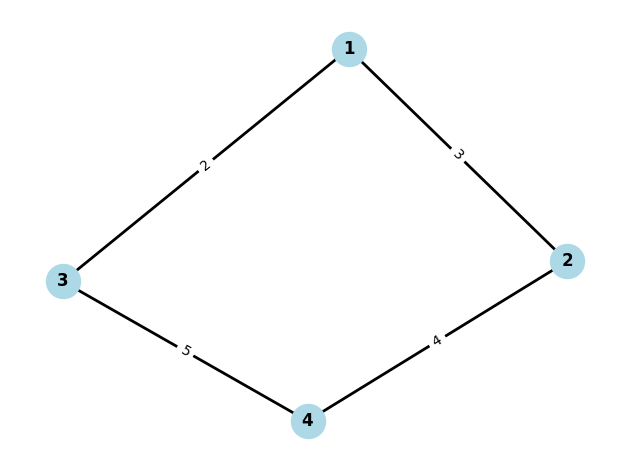

In [4]:
# przykładowy graf eulerowski
g_0 = ChinesePostman(edges=[
    (1, 2, 3),
    (1, 3, 2),
    (2, 4, 4),
    (3, 4, 5)
])
g_0.plot()

In [5]:
cost, extra = g_0.chinese_postman()
circuit = g_0.eulerian_circuit(extra_edges=extra)
print("Trasa listonosza:", circuit)

Wierzchołki o nieparzystym stopniu: []
Graf eulerowski - przez każdą krawędź przejdzie dokładnie raz.
Koszt bazowy (suma wag krawędzi): 14
Dodatkowy koszt (zduplikowane ścieżki): 0
Minimalny koszt trasy listonosza: 14
Trasa listonosza: [1, 2, 4, 3, 1]


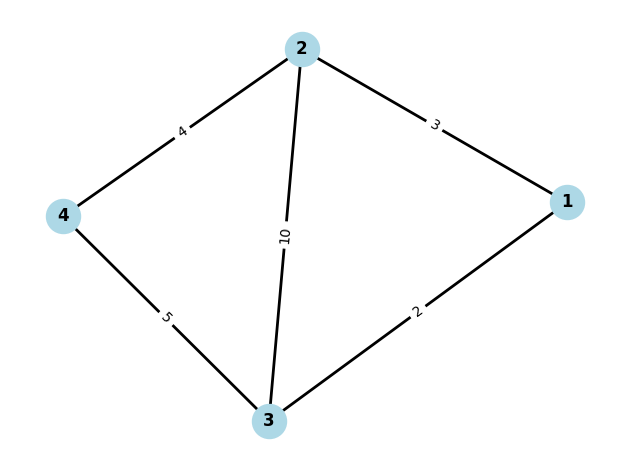

In [6]:
# przykładowy graf półeulerowski
g_1 = copy.deepcopy(g_0)
g_1.add_edge([2,3], 10)
g_1.plot()

In [7]:
cost, extra = g_1.chinese_postman()
circuit = g_1.eulerian_circuit(extra_edges=extra)
print("Trasa listonosza:", circuit)

Wierzchołki o nieparzystym stopniu: [2, 3]
Koszt bazowy (suma wag krawędzi): 24
Dodatkowy koszt (zduplikowane ścieżki): 5
Minimalny koszt trasy listonosza: 29
Trasa listonosza: [1, 2, 1, 3, 2, 4, 3, 1]


In [8]:
sp_1 = g_1._all_pairs_shortest_paths([2,3])
print(sp_1)
print(g_1._min_weight_matching([2,3], sp_1))

{(2, 3): (5, [2, 1, 3]), (3, 2): (5, [3, 1, 2])}
(5, [(2, 3, [2, 1, 3])])


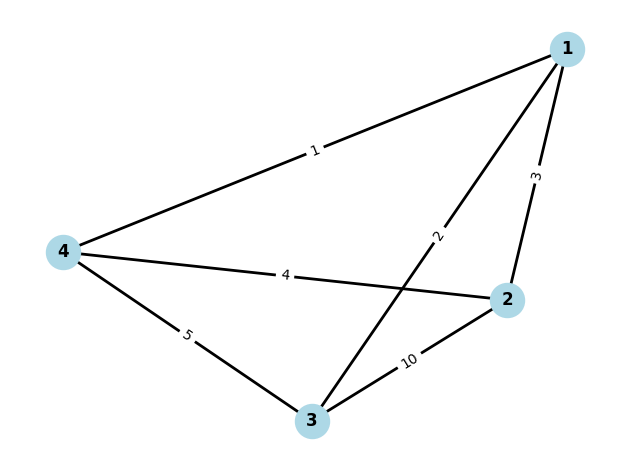

In [9]:
# przykładowy graf nieeulerowski
g_2 = copy.deepcopy(g_1)
g_2.add_edge([1,4], 1)
g_2.plot()

In [10]:
cost, extra = g_2.chinese_postman()
circuit = g_2.eulerian_circuit(extra_edges=extra)
print("Trasa listonosza:", circuit)

Wierzchołki o nieparzystym stopniu: [1, 2, 3, 4]
Koszt bazowy (suma wag krawędzi): 25
Dodatkowy koszt (zduplikowane ścieżki): 6
Minimalny koszt trasy listonosza: 31
Trasa listonosza: [1, 2, 1, 3, 1, 4, 2, 3, 4, 1]


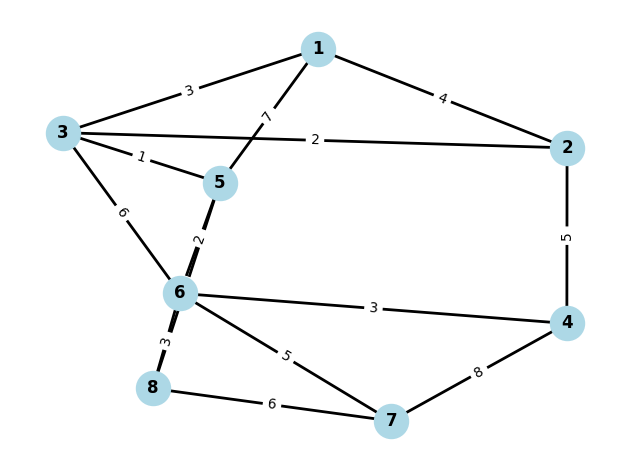

Wierzchołki o nieparzystym stopniu: [1, 2, 4, 6, 7, 8]
Koszt bazowy (suma wag krawędzi): 59
Dodatkowy koszt (zduplikowane ścieżki): 13
Minimalny koszt trasy listonosza: 72
Trasa listonosza: 1 -> 2 -> 1 -> 3 -> 2 -> 4 -> 6 -> 3 -> 5 -> 6 -> 4 -> 7 -> 6 -> 8 -> 7 -> 8 -> 5 -> 1


In [13]:
# przykład z 10 wierzchołkami
g = ChinesePostman(edges=[
    (1, 2, 4),
    (1, 3, 3),
    (1, 5, 7),
    (2, 3, 2),
    (2, 4, 5),
    (3, 5, 1),
    (3, 6, 6),
    (4, 6, 3),
    (4, 7, 8),
    (5, 6, 2),
    (5, 8, 4),
    (6, 7, 5),
    (6, 8, 3),
    (7, 8, 6)
])

g.plot()
cost, extra = g.chinese_postman()
circuit = g.eulerian_circuit(extra_edges=extra)
print("Trasa listonosza:", " -> ".join(str(v) for v in circuit))